1.8557289941990311
59.940442767379906
[0.286374288859651, 0.017867637428573613, 0.055014290247247875, 0.03611871670115141]
[0. 0. 0. 0. 0.]
1.0510616568380087
90
90


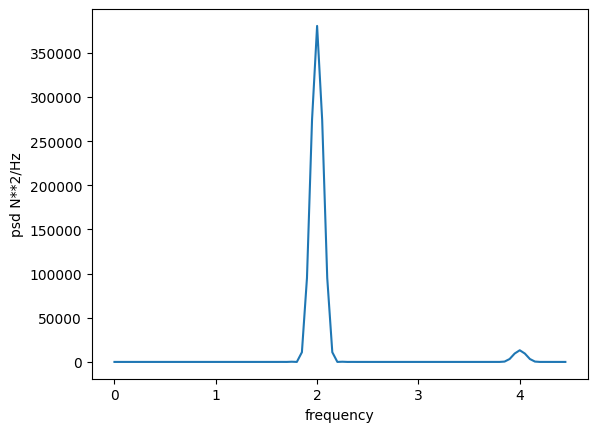

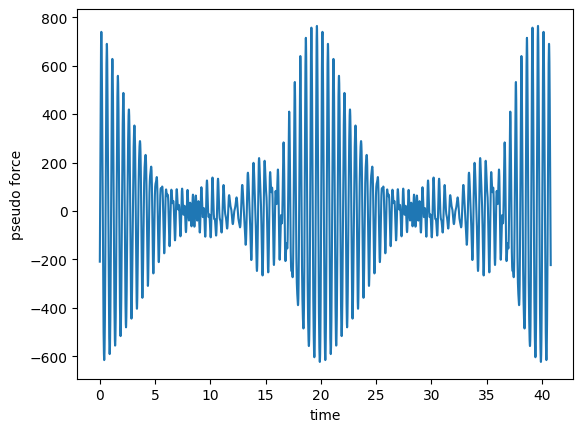

In [2]:
import math
import numpy as np
import random
from matplotlib import pyplot as plt
from pedestrian import *
from scipy.signal import welch,periodogram
from solver import Newmarkpseudo_HSI, Phi_matrix,accdyn_super
from matrix import bridge
from pseudo_excitation import *

#step 1 setup beam and pedestrians

#beam

length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 3

#ped
numped = 1
pedmass = 80    #kg
peddamp = 0    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 0 #Hz

#ped
kped=(2*np.pi*pedBodyF)**2*pedmass
cped = (2*np.pi*pedBodyF)*2*peddamp*pedmass

modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12

#set time info
hht=0.01

#initial possition vector.......formultiple ped all these would become matrices

#xrb=np.zeros(1,numped)
xrb=[0]

Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = 3,  )                   #modes


N_bridge = 3




# probabilitstic parameters
mean_pace = 2 #Hz  2005 pachi
pace_COV = 0.1

mean_mass= pedmass #kg
mass_COV= 0.17 #from butz 2008

mean_velocity = 1.3
std_velocity = 0.12 #pachi 2005

mean_alpha = np.array([0.41 * (mean_pace - 0.95),
                0.069 + 0.0056 * mean_pace,
                .033 + 0.0064 * mean_pace,
                0.013 + 0.0065 *mean_pace])

alpha_COV= np.array([0.17,0.4,0.4,0.4])


alpha_std = mean_alpha*alpha_COV

# Generate a random variable from a normal distribution with considered mean and std_dev from literiture

randomPace = random.gauss(mean_pace, pace_COV*mean_pace)
randomMass = random.gauss(mean_mass, mass_COV*mean_mass)
randomAlpha = [random.gauss(mean_alpha[i], alpha_std[i]) for i in range(len(alpha_COV))]
#randomPhase = [random.uniform(0, 2 * math.pi) for i in range(len(mean_alpha)+1)]
randomVelocity = random.gauss(mean_velocity,std_velocity)
randomPhase = np.zeros(5)


print(randomPace)
print(randomMass)
print(randomAlpha)
print(randomPhase)
print(randomVelocity)

t = np.array(np.arange(0, (length+1) / pedvelocity, hht))   #for the testing length was made 10

Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
         iSync=0)


'''Human = Pedestrian(
         mass = randomMass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = 2 ,    #Hz
         phase = randomPhase,
         location = pedInlocation,
         velocity = randomVelocity,
         
         iSync=0)'''

#ped = RandPedestrian(randomMass, randomPace, randomPhase, randomAlpha)
n=1
numped=1
#j=np.size(t)
xr=[0]
#force_at_time_t = np.zeros(np.size(t))

#F=np.zeros((N_bridge,np.size(t)))
#for i in range (np.size(t)):
     
force_at_time_t = calcPedForce(Human,t)

fs=1/hht
frequencies, psd = welch(force_at_time_t, fs=fs,nperseg=1000, nfft=2000 )
frequencies = np.array(frequencies)
psd = np.array(psd)
frequencies=frequencies[frequencies<(4.5)] #adjust range of frequency range suitable for analysis
psd=psd[:np.size(frequencies)]

print(np.size(frequencies))
print(np.size(psd))

plt.plot(frequencies,psd)
plt.xlabel("frequency")
plt.ylabel("psd N**2/Hz")
plt.show()


pseudo_force1 = pseudo_force(psd,frequencies,t)
plt.plot(t,pseudo_force1)
plt.xlabel("time")
plt.ylabel("pseudo force")
plt.show()


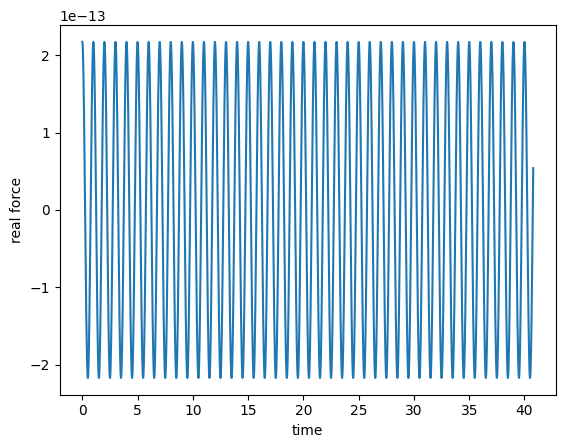

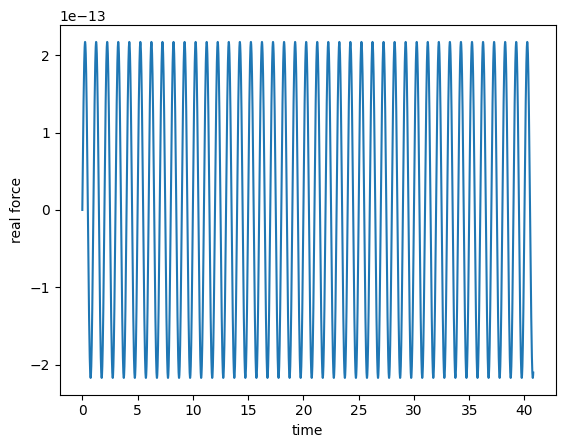

In [13]:
real,imaginary = pseudo_excitation(psd,frequencies,50,1.25,t)
plt.plot(t.flatten(),real[[20],:].T)
plt.xlabel("time")
plt.ylabel("real force")
plt.show()

plt.plot(t.flatten(),imaginary[[20],:].T)
plt.xlabel("time")
plt.ylabel("real force")
plt.show()

[[ 0.00000000e+00  1.64707134e-18  3.26619030e-18 ... -2.53879344e-18
  -4.15930671e-18  0.00000000e+00]
 [ 0.00000000e+00  3.10526621e-18  5.45965011e-18 ... -1.19526720e-18
  -3.57733975e-18  0.00000000e+00]
 [ 0.00000000e+00  3.73091594e-18  3.81500282e-18 ... -1.54411659e-18
  -2.29933763e-18  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
[[ 0.00000000e+00  2.62458935e-08  5.20461098e-08 ... -4.04943570e-08
  -6.63666401e-08  0.00000000e+00]
 [ 0.00000000e+00  4.94820619e-08  8.69984118e-08 ... -1.90451751e-08
  -5.70083569e-08  0.00000000e+00]
 [ 0.00000000e+00  5.94517189e-08  6.07910469e-08 ... -2.46053196e-08
  -3.66405490e-08  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
[[ 0.00000000e+00  2.94905501e-18  5.84794529e-18 ... -4.56322596e-18
  -7.48708749e-18  0.00000000e+00]
 [ 0.00000000e+00  5.55992969e-18  9.77519708e-18 ...

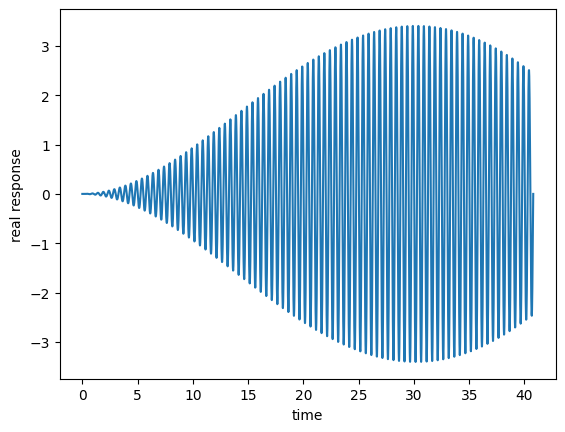

In [14]:

Real_responce = np.zeros((np.size(frequencies),np.size(t)))
for i in range(np.size(frequencies)):
    realF=np.array(real[[i],:])
    #print(realF)
    _,_,ddu = Newmarkpseudo_HSI(Human, Bridge,numped,N_bridge,length,hht,pedvelocity,[pedmass],[kped],[cped],[0],linearMass,realF)
    #case_pedestrian,case_bridge,numped,N_bridge, lb, hht, v, mped,kped,cped,xrb, rho,force
    Real_responce[[i],:]=accdyn_super(Bridge,ddu,x_interested,hht)

plt.plot(t.flatten(),Real_responce[[40],:].T)
plt.xlabel("time")
plt.ylabel("real response")
#plt.savefig("plot.png",dpi=300Z)
plt.show()
#plt.semilogy(frequencies,psd)


In [15]:

import pickle
with open('Real_responce_No_HSI.pkl', 'wb') as f:
    pickle.dump(Real_responce, f)

print("Matrix saved to Real_responce_No_HSI.pkl")


Matrix saved to Real_responce_No_HSI.pkl


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0.00000000e+00 0.00000000e+00 1.64907490e-10 ... 1.06097024e-08
  1.03552510e-08 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 3.10904069e-10 ... 1.12808900e-09
  1.00841046e-09 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 3.73544515e-10 ... 2.35836815e-10
  8.12342474e-11 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]
[[0.00000000e+00 0.00000000e+00 3.70586629e-20 ... 2.39328912e-18
  2.33593836e-18 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 6.98675912e-20 ... 2.53569634e-19
  2.26672332e-19 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 8.39443997e-20 ... 5.30011656e-20
  1.82569624e-20 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]
[[0.00000000e+00 0.00000000e+00 1.50902557e-09 ... 9.80723442e-08
  9.57254519e-08 0.00000000e+00]
 [0.00

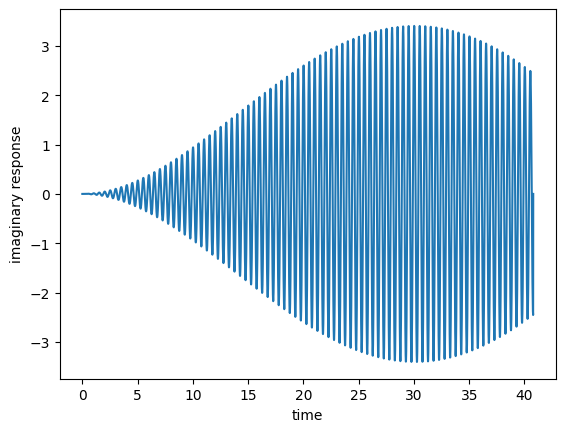

In [16]:

imag_responce = np.zeros((np.size(frequencies),np.size(t)))
for i in range(np.size(frequencies)):
    imagF=np.array(imaginary[[i],:])
    #print(realF)
    _,_,ddu = Newmarkpseudo_HSI(Human, Bridge,numped,N_bridge,length,hht,pedvelocity,[pedmass],[kped],[cped],[0],linearMass,imagF)
    #case_pedestrian,case_bridge,numped,N_bridge, lb, hht, v, mped,kped,cped,xrb, rho,force
    imag_responce[[i],:]=accdyn_super(Bridge,ddu,x_interested,hht)

plt.plot(t.flatten(),imag_responce[[40],:].T)
plt.xlabel("time")
plt.ylabel("imaginary response")
#plt.savefig("plot.png",dpi=300Z)
plt.show()
#plt.semilogy(frequencies,psd)   

In [17]:
import pickle
with open('imag_responce_No_HSI.pkl', 'wb') as f:
    pickle.dump(imag_responce, f)

print("Matrix saved to imag_responce_No_HSI.pkl")

Matrix saved to imag_responce_No_HSI.pkl


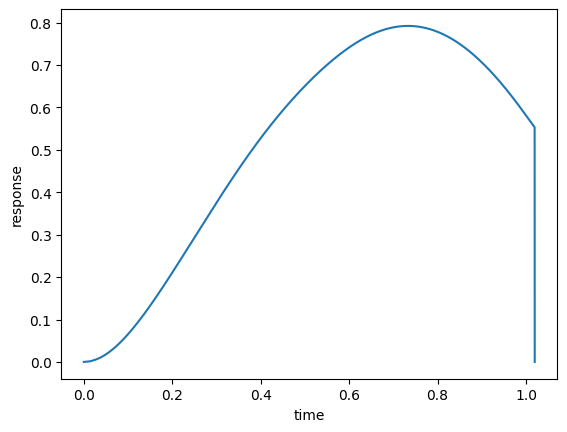

Matrix saved to deterministic_RMS_No_HSI.pkl


In [5]:

with open('Real_responce_No_HSI.pkl', 'rb') as f1:
    Real_responce_No_HSI = pickle.load(f1)
with open('imag_responce_No_HSI.pkl', 'rb') as f2:
    imag_responce_No_HSI = pickle.load(f2)

Y=np.zeros((1,np.size(t)))
delta_f= frequencies[5]-frequencies[4]
for i in range(np.size(t)):
    for j in range(np.size(frequencies)):
        Y[0,[i]] += (Real_responce_No_HSI[[j],[i]]**2 + imag_responce_No_HSI[[j],[i]]**2)*delta_f

deterministic_RMS_No_HSI=np.sqrt(Y)
Xnormal=pedvelocity*t/length

plt.plot(Xnormal.flatten(),deterministic_RMS_No_HSI.T)
plt.xlabel("time")
plt.ylabel("response")

plt.show()

import pickle
with open('deterministic_RMS_No_HSI.pkl', 'wb') as f:
    pickle.dump(deterministic_RMS_No_HSI, f)

print("Matrix saved to deterministic_RMS_No_HSI.pkl")

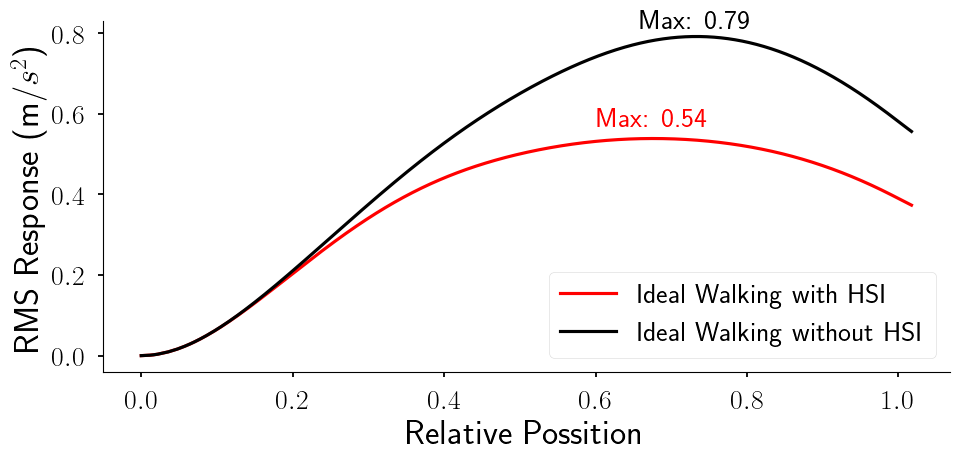

Maximum 0.5-second RMS value: 0.5389 m/s^2 
Maximum 0.5-second RMS value: 0.7921 m/s^2 


In [38]:

from matplotlib import rc
#setting the matplotlib
#setting the matplotlib
plt.style.use('seaborn-v0_8-talk')#('seaborn-talk')#
#plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.serif'] = 'Computer Modern'
plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 20#10
plt.rcParams['axes.labelsize'] = 25#8
#plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 25#8
plt.rcParams['xtick.labelsize'] = 20#8
plt.rcParams['ytick.labelsize'] = 20#8
plt.rcParams['legend.fontsize'] = 20#10
plt.rcParams['figure.titlesize'] = 20#12
rc('text', usetex=True)

import pickle
with open('deterministic_RMS.pkl', 'rb') as f3:
    deterministic_RMS_with_HSI = pickle.load(f3)
with open('deterministic_RMS_No_HSI.pkl', 'rb') as f4:
    deterministic_RMS_No_HSI = pickle.load(f4)
with open('SIMSM_326.pkl', 'rb') as f5:
    SIMSM326 = pickle.load(f5)
with open('ZIV_SM_withHSI.pkl', 'rb') as f6:
    ZIV_SM_withHSI = pickle.load(f6)
with open('SIMSM_309.pkl', 'rb') as f7:
    SIMSM_309 = pickle.load(f7)
with open('SIMSM_324.pkl', 'rb') as f8:
    SIMSM_324 = pickle.load(f8)
with open('SIMSM_32.pkl', 'rb') as f8:
    SIMSM_32 = pickle.load(f8)

# Remove the last 10 points from x
x_trimmed = Xnormal[:-10]
y_flattened  = deterministic_RMS_with_HSI.flatten()
y2_flattened  = deterministic_RMS_No_HSI.flatten()
# Adjust y to match the length of x_trimmed
y_trimmed = y_flattened [:len(x_trimmed)]
y2_trimmed = y2_flattened [:len(x_trimmed)]

maxvalue1 = np.max(y_trimmed)
maxvalue2 = np.max(y2_trimmed)
max_x = x_trimmed[np.argmax(y_trimmed)]
max_x2 = x_trimmed[np.argmax(y2_trimmed)]

plt.figure(figsize=(10,5))
plt.plot(x_trimmed.flatten(), y_trimmed.T, color='red')
plt.plot(x_trimmed.flatten(), y2_trimmed.T,color='black')
#plt.plot(Xnormal.flatten(),SIMSM_324.T,color='yellow')
#plt.plot(Xnormal.flatten(),ZIV_SM_withHSI.T,color='black')
#plt.plot(Xnormal.flatten(),SIMSM_32.T,color='yellow')
#plt.plot(Xnormal.flatten(),SIMSM_309.T)
plt.annotate(f'Max: {maxvalue1:.2f}', xy=(max_x, maxvalue1), xytext=(max_x, maxvalue1 + 0.03),
             ha='center',color='red', fontsize=20)
plt.annotate(f'Max: {maxvalue2:.2f}', xy=(max_x2, maxvalue2), xytext=(max_x2, maxvalue2 + 0.02),
             ha='center',color='black', fontsize=20)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlabel("Relative Possition")
plt.ylabel("RMS Response (m/$s^2$)")
plt.legend(["Ideal Walking with HSI","Ideal Walking without HSI"])
plt.tight_layout()
plt.savefig("with and without HSI new2.pdf", format='pdf', dpi=300)

plt.show()

# Find the maximum RMS value and its corresponding time
maxvalue1 = np.max(y_trimmed)
maxvalue2 = np.max(y2_trimmed)
#maxvalue3 = np.max(ZIV_SM_withHSI)
#maxvalue4 = np.max(SIMSM_32)
# Print the maximum RMS value and its corresponding time
print(f"Maximum 0.5-second RMS value: {maxvalue1:.4f} m/s^2 ")
#print(f"Maximum 0.5-second RMS value: {maxvalue4:.4f} m/s^2 ")
#print(f"Maximum 0.5-second RMS value: {maxvalue3:.4f} m/s^2 ")
print(f"Maximum 0.5-second RMS value: {maxvalue2:.4f} m/s^2 ")

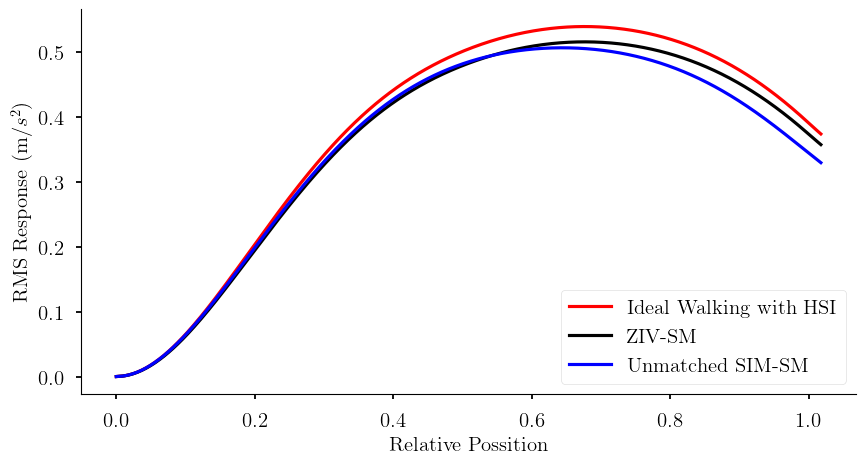

Maximum 0.5-second RMS value: 0.5389 m/s^2 
Maximum 0.5-second RMS value: 0.5153 m/s^2 
Maximum 0.5-second RMS value: 0.5062 m/s^2 


In [25]:
from matplotlib import rc
#setting the matplotlib
#setting the matplotlib
plt.style.use('seaborn-v0_8-talk')#('seaborn-talk')#
#plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.serif'] = 'Computer Modern'
plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 10#10
plt.rcParams['axes.labelsize'] = 15#8
#plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 15#8
plt.rcParams['xtick.labelsize'] = 15#8
plt.rcParams['ytick.labelsize'] = 15#8
plt.rcParams['legend.fontsize'] = 15#10
plt.rcParams['figure.titlesize'] = 15#12
rc('text', usetex=True)
with open('deterministic_RMS.pkl', 'rb') as f7:
    deterministic_RMS_with_HSI = pickle.load(f7)
with open('ZIV_SM_withHSI.pkl', 'rb') as f8:
    ZIV_SM_withHSI = pickle.load(f8)
with open('deterministic_RMS_stochastic_with_HSI.pkl', 'rb') as f9:
    deterministic_RMS_stochastic_with_HSI = pickle.load(f9)

# Remove the last 10 points from x
x_trimmed = Xnormal[:-10]
y_flattened  = deterministic_RMS_with_HSI.flatten()
y2_flattened  = ZIV_SM_withHSI.flatten()
y3_flattened  = deterministic_RMS_stochastic_with_HSI.flatten()

# Adjust y to match the length of x_trimmed
y_trimmed = y_flattened [:len(x_trimmed)]
y2_trimmed = y2_flattened [:len(x_trimmed)]
y3_trimmed = y3_flattened [:len(x_trimmed)]

maxvalue1 = np.max(y_trimmed)
maxvalue2 = np.max(y2_trimmed)
maxvalue3 = np.max(y3_trimmed)
max_x = x_trimmed[np.argmax(y_trimmed)]
max_x2 = x_trimmed[np.argmax(y2_trimmed)]
max_x3 = x_trimmed[np.argmax(y3_trimmed)]

plt.figure(figsize=(10,5))
plt.plot(x_trimmed.flatten(), y_trimmed.T, color='red')
plt.plot(x_trimmed.flatten(), y2_trimmed.T,color='black')
plt.plot(x_trimmed.flatten(), y3_trimmed.T,color='blue')
#plt.plot(Xnormal.flatten(),SIMSM_324.T,color='yellow')
#plt.plot(Xnormal.flatten(),ZIV_SM_withHSI.T,color='black')
#plt.plot(Xnormal.flatten(),SIMSM_32.T,color='yellow')
#plt.plot(Xnormal.flatten(),SIMSM_309.T)
#plt.annotate(f'Max: {maxvalue1:.2f}', xy=(max_x, maxvalue1), xytext=(max_x, maxvalue1 + 0.02),
           #  ha='center',color='red', fontsize=11)
#plt.annotate(f'Max: {maxvalue2:.2f}', xy=(max_x2, maxvalue2), xytext=(max_x2, maxvalue2 + 0.005),
             #ha='center',color='black', fontsize=11)
#plt.annotate(f'Max: {maxvalue3:.2f}', xy=(max_x3, maxvalue3), xytext=(max_x3, maxvalue3 - 0.03),
            #    ha='center',color='blue', fontsize=11)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlabel("Relative Possition")
plt.ylabel("RMS Response (m/$s^2$)")
plt.legend(["Ideal Walking with HSI","ZIV-SM","Unmatched SIM-SM"])
plt.savefig("ideal ZIVSM unmacthced SIMSM3", format='pdf', dpi=300)
plt.show()

# Find the maximum RMS value and its corresponding time
maxvalue1 = np.max(y_trimmed)
maxvalue2 = np.max(y2_trimmed)
maxvalue3 = np.max(y3_trimmed)

print(f"Maximum 0.5-second RMS value: {maxvalue1:.4f} m/s^2 ")
print(f"Maximum 0.5-second RMS value: {maxvalue2:.4f} m/s^2 ")
print(f"Maximum 0.5-second RMS value: {maxvalue3:.4f} m/s^2 ")

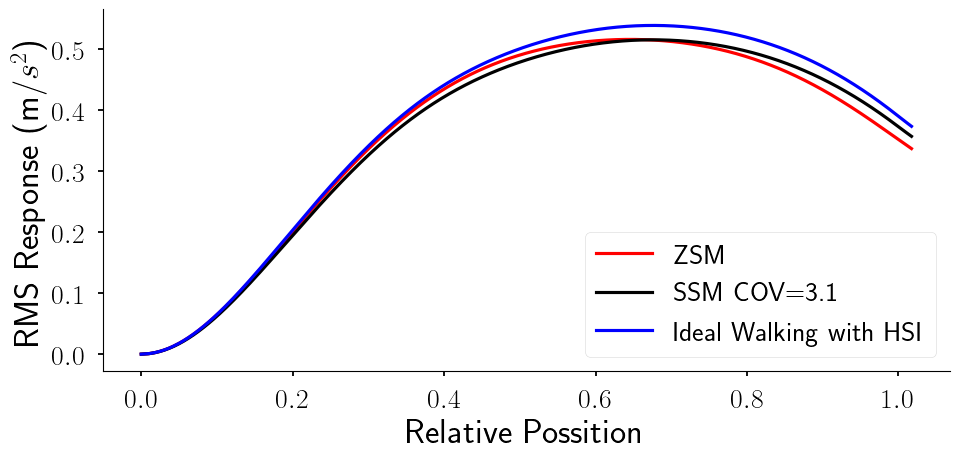

Maximum 0.5-second RMS value: 0.5160 m/s^2 
Maximum 0.5-second RMS value: 0.5153 m/s^2 
Maximum 0.5-second RMS value: 0.5389 m/s^2 


In [41]:
from matplotlib import rc
import pickle
#setting the matplotlib
#setting the matplotlib
plt.style.use('seaborn-v0_8-talk')#('seaborn-talk')#
#plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.serif'] = 'Computer Modern'
plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 20#10
plt.rcParams['axes.labelsize'] = 25#8
#plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 25#8
plt.rcParams['xtick.labelsize'] = 20#8
plt.rcParams['ytick.labelsize'] = 20#8
plt.rcParams['legend.fontsize'] = 20#10
plt.rcParams['figure.titlesize'] = 20#12
rc('text', usetex=True)
Xnormal=pedvelocity*t/length
with open('SIMSM_309.pkl', 'rb') as f7:
    SIMSM_309 = pickle.load(f7)
with open('ZIV_SM_withHSI.pkl', 'rb') as f8:
    ZIV_SM_withHSI = pickle.load(f8)
with open('deterministic_RMS.pkl', 'rb') as f7:
    deterministic_RMS_with_HSI = pickle.load(f7)

# Remove the last 10 points from x
x_trimmed = Xnormal[:-10]
y_flattened  = SIMSM_309.flatten()
y2_flattened  = ZIV_SM_withHSI.flatten()
y3_flattened  =  deterministic_RMS_with_HSI.flatten()

# Adjust y to match the length of x_trimmed
y_trimmed = y_flattened [:len(x_trimmed)]
y2_trimmed = y2_flattened [:len(x_trimmed)]
y3_trimmed = y3_flattened [:len(x_trimmed)]

maxvalue1 = np.max(y_trimmed)
maxvalue2 = np.max(y2_trimmed)
maxvalue3 = np.max(y3_trimmed)
max_x = x_trimmed[np.argmax(y_trimmed)]
max_x2 = x_trimmed[np.argmax(y2_trimmed)]
max_x3 = x_trimmed[np.argmax(y3_trimmed)]

plt.figure(figsize=(10,5))
plt.plot(x_trimmed.flatten(), y_trimmed.T, color='red')
plt.plot(x_trimmed.flatten(), y2_trimmed.T,color='black')
plt.plot(x_trimmed.flatten(), y3_trimmed.T,color='blue')
#plt.plot(Xnormal.flatten(),SIMSM_324.T,color='yellow')
#plt.plot(Xnormal.flatten(),ZIV_SM_withHSI.T,color='black')
#plt.plot(Xnormal.flatten(),SIMSM_32.T,color='yellow')
#plt.plot(Xnormal.flatten(),SIMSM_309.T)
#plt.annotate(f'Max: {maxvalue1:.2f}', xy=(max_x, maxvalue1), xytext=(max_x-0.05, maxvalue1 - 0.05),
             #ha='center',color='red', fontsize=20)
#plt.annotate(f'Max: {maxvalue2:.2f}', xy=(max_x2, maxvalue2), xytext=(max_x2+0.05, maxvalue2 - 0.05),
            # ha='center',color='black', fontsize=20)
#plt.annotate(f'Max: {maxvalue3:.2f}', xy=(max_x3, maxvalue3), xytext=(max_x3, maxvalue3 - 0.03),
#                ha='center',color='blue', fontsize=9)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlabel("Relative Possition")
plt.ylabel("RMS Response (m/$s^2$)")
plt.legend(["ZSM","SSM COV=3.1%","Ideal Walking with HSI"])
plt.tight_layout()
plt.savefig("SIMSM_mached_ZIVSM6", format='pdf', dpi=300)
plt.show()

# Find the maximum RMS value and its corresponding time
maxvalue1 = np.max(y_trimmed)
maxvalue2 = np.max(y2_trimmed)
#maxvalue3 = np.max(y3_trimmed)

print(f"Maximum 0.5-second RMS value: {maxvalue1:.4f} m/s^2 ")
print(f"Maximum 0.5-second RMS value: {maxvalue2:.4f} m/s^2 ")
print(f"Maximum 0.5-second RMS value: {maxvalue3:.4f} m/s^2 ")

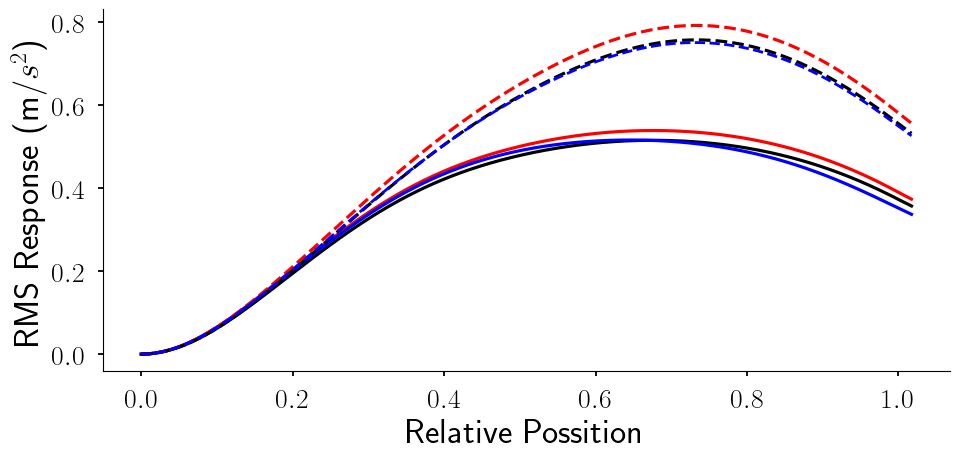

Maximum 0.5-second RMS value: 0.5389 m/s^2 
Maximum 0.5-second RMS value: 0.5153 m/s^2 
Maximum 0.5-second RMS value: 0.5160 m/s^2 


In [43]:
from matplotlib import rc
#setting the matplotlib
#setting the matplotlib
plt.style.use('seaborn-v0_8-talk')#('seaborn-talk')#
#plt.rcParams['font.family'] = 'serif'
#plt.rcParams['font.serif'] = 'Computer Modern'
plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 20#10
plt.rcParams['axes.labelsize'] = 25#8
#plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 25#8
plt.rcParams['xtick.labelsize'] = 20#8
plt.rcParams['ytick.labelsize'] = 20#8
plt.rcParams['legend.fontsize'] = 20#10
plt.rcParams['figure.titlesize'] = 20#12
rc('text', usetex=True)
import pickle
with open('deterministic_RMS.pkl', 'rb') as f7:
    deterministic_RMS_with_HSI = pickle.load(f7)
with open('ZIV_SM_withHSI.pkl', 'rb') as f8:
    ZIV_SM_withHSI = pickle.load(f8)
with open('SIMSM_309.pkl', 'rb') as f7:
    SIMSM_309 = pickle.load(f7)

with open('deterministic_RMS_No_HSI.pkl', 'rb') as f10:
    deterministic_RMS_No_HSI = pickle.load(f10)
with open('ZIV_SM_NOHSI.pkl', 'rb') as f11:
    ZIV_SMNOHSI = pickle.load(f11)
with open('SIMSM_3_35COV2_NOHSI.pkl', 'rb') as f12:
    SIMSM_COV_5_NOHSI = pickle.load(f12)

Xnormal=pedvelocity*t/length
#Remove the last 10 points from x
x_trimmed = Xnormal[:-10]
y_flattened  = deterministic_RMS_with_HSI.flatten()
y2_flattened  = ZIV_SM_withHSI.flatten()
y3_flattened  = SIMSM_309.flatten()
y4_flattened  = deterministic_RMS_No_HSI.flatten()
y5_flattened  = ZIV_SMNOHSI.flatten()
y6_flattened  = SIMSM_COV_5_NOHSI.flatten()

# Adjust y to match the length of x_trimmed
y_trimmed = y_flattened [:len(x_trimmed)]
y2_trimmed = y2_flattened [:len(x_trimmed)]
y3_trimmed = y3_flattened [:len(x_trimmed)]
y4_trimmed = y4_flattened [:len(x_trimmed)]
y5_trimmed = y5_flattened [:len(x_trimmed)]
y6_trimmed = y6_flattened [:len(x_trimmed)]

maxvalue1 = np.max(y_trimmed)
maxvalue2 = np.max(y2_trimmed)
maxvalue3 = np.max(y3_trimmed)
maxvalue4 = np.max(y4_trimmed)
maxvalue5 = np.max(y5_trimmed)
maxvalue6 = np.max(y6_trimmed)

max_x = x_trimmed[np.argmax(y_trimmed)]
max_x2 = x_trimmed[np.argmax(y2_trimmed)]
max_x3 = x_trimmed[np.argmax(y3_trimmed)]
max_x4 = x_trimmed[np.argmax(y4_trimmed)]
max_x5 = x_trimmed[np.argmax(y5_trimmed)]
max_x6 = x_trimmed[np.argmax(y6_trimmed)]

plt.figure(figsize=(10,5))
plt.plot(x_trimmed.flatten(), y_trimmed.T, color='red')
plt.plot(x_trimmed.flatten(), y2_trimmed.T,color='black')
plt.plot(x_trimmed.flatten(), y3_trimmed.T,color='blue')
plt.plot(x_trimmed.flatten(), y4_trimmed.T,color='red',linestyle='--')
plt.plot(x_trimmed.flatten(), y5_trimmed.T,color='black',linestyle='--')
plt.plot(x_trimmed.flatten(), y6_trimmed.T,color='blue',linestyle='--',linewidth=2)

#plt.annotate(f'Max: {maxvalue1:.2f}', xy=(max_x, maxvalue1), xytext=(max_x, maxvalue1),
          #   ha='center',color='red', fontsize=9)
#plt.annotate(f'Max: {maxvalue2:.2f}', xy=(max_x2, maxvalue2), xytext=(max_x2, maxvalue2),
          #   ha='center',color='black', fontsize=9)
#plt.annotate(f'Max: {maxvalue3:.2f}', xy=(max_x3, maxvalue3), xytext=(max_x3, maxvalue3),
           #    ha='center',color='blue', fontsize=9)
#plt.annotate(f'Max: {maxvalue4:.2f}', xy=(max_x, maxvalue1), xytext=(max_x, maxvalue4),
            # ha='center',color='red', fontsize=9)
#plt.annotate(f'Max: {maxvalue5:.2f}', xy=(max_x2, maxvalue2), xytext=(max_x2, maxvalue5),
            # ha='center',color='black', fontsize=9)
#plt.annotate(f'Max: {maxvalue6:.2f}', xy=(max_x3, maxvalue3), xytext=(max_x3, maxvalue6),
               # ha='center',color='blue', fontsize=9)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlabel("Relative Possition")
plt.ylabel("RMS Response (m/$s^2$)")
#plt.legend(["Ideal Walking with HSI","ZSM with HSI","SSM with HSI","Ideal Walking without HSI","ZSM without HSI","Matched SSM without HSI"])
plt.tight_layout()
plt.savefig("conclusion figure9", format='pdf', dpi=300)
plt.show()

# Find the maximum RMS value and its corresponding time
maxvalue1 = np.max(y_trimmed)
maxvalue2 = np.max(y2_trimmed)
maxvalue3 = np.max(y3_trimmed)

print(f"Maximum 0.5-second RMS value: {maxvalue1:.4f} m/s^2 ")
print(f"Maximum 0.5-second RMS value: {maxvalue2:.4f} m/s^2 ")
print(f"Maximum 0.5-second RMS value: {maxvalue3:.4f} m/s^2 ")